1. Top 10 Städte (Horizontales Balkendiagramm)
Frage: In welchen Städten gibt es die meisten Stellenangebote für Business Intelligence?  

2. Top 5 Firmen (Lollipop-Chart)
Frage: Welche Arbeitgeber sind derzeit am aktivsten bei der Suche nach BI-Spezialisten?  


3. Region vs. Firma (Heatmap)
Frage: Wie verteilt sich die Einstellungsaktivität der Top-Firmen über die verschiedenen Bundesländer?  
 

4. Stellenverteilung (Tortendiagramm)
Frage: Wie hoch ist der prozentuale Marktanteil der einzelnen Regionen an der Gesamtzahl der Ausschreibungen?  

5. IT-Berufsfelder nach Region (Gestapeltes Balkendiagramm)
Frage: Wie unterscheidet sich die Zusammensetzung der IT-Kategorien (BI vs. andere) zwischen den Bundesländern?  


6. BI vs. Fullstack Vergleich (Vergleichs-Balkendiagramm)
Frage: Wie verhält sich die Nachfrage nach Business Intelligence Experten im Vergleich zu Fullstack-Entwicklern in den Regionen?

7. Stelle verteilen in Map

<>:6: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
<>:6: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
C:\Users\codin\AppData\Local\Temp\ipykernel_8796\2233603287.py:6: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
  df = pd.read_json('D:\Workspace2\Project BI-Stelle Analysis\locations_data.json')


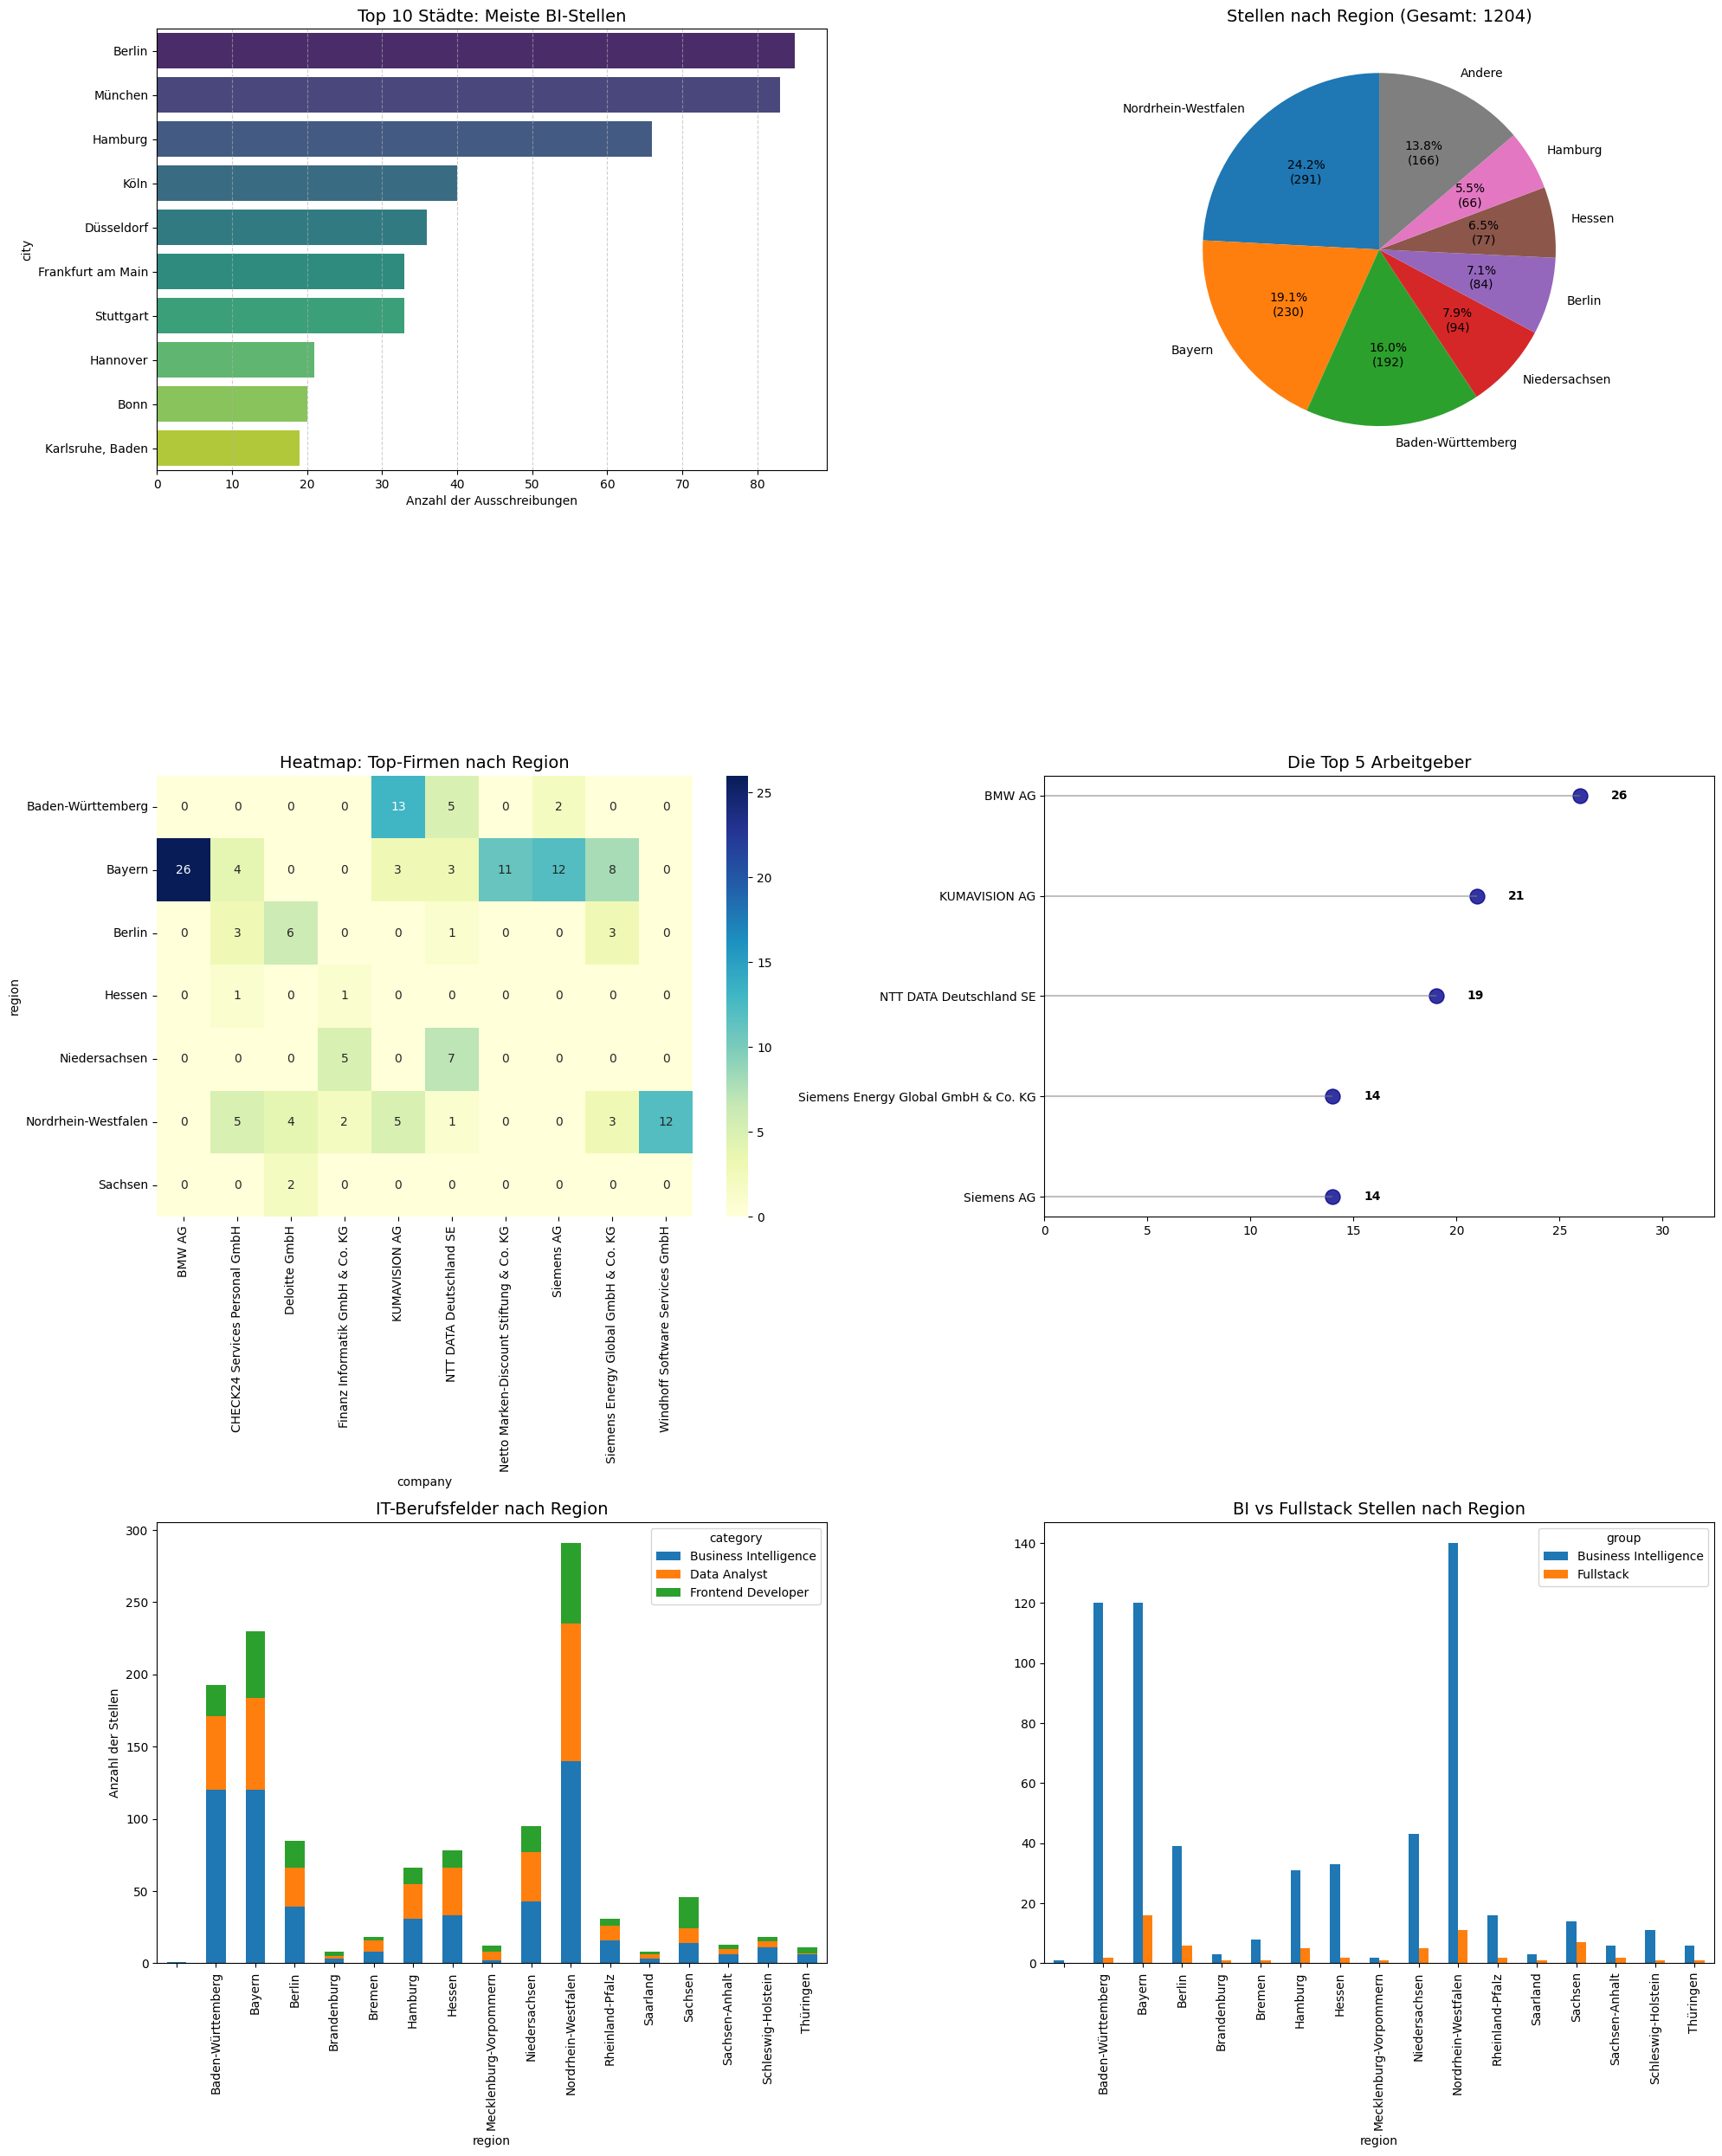

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_json('.\locations_data.json')

# Create a figure with a 3x2 grid of subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 25))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- 1. TOP 10 CITIES (Horizontal Bar) ---
city_counts = df['city'].value_counts().head(10)
sns.barplot(x=city_counts.values, y=city_counts.index, palette='viridis', hue=city_counts.index, legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Top 10 Städte: Meiste BI-Stellen', fontsize=14)
axes[0, 0].set_xlabel('Anzahl der Ausschreibungen')
axes[0, 0].grid(axis='x', linestyle='--', alpha=0.6)

# --- 2. REGION DISTRIBUTION (Pie Chart) - MOVED TO [0, 1] ---
region_counts = df['region'].value_counts()
total = region_counts.sum()
threshold = 0.05
small = region_counts[region_counts / total < threshold]
large = region_counts[region_counts / total >= threshold].copy()
if not small.empty:
    large.loc['Andere'] = small.sum()

axes[0, 1].pie(large, labels=large.index, autopct=lambda p: f'{p:.1f}%\n({int(p*total/100)})', startangle=90)
axes[0, 1].set_title(f'Stellen nach Region (Gesamt: {total})', fontsize=14)

# --- 3. REGION VS. FIRMA (Heatmap) ---
top_10_regions = df['region'].value_counts().head(10).index
top_10_companies = df['company'].value_counts().head(10).index
subset = df[df['region'].isin(top_10_regions) & df['company'].isin(top_10_companies)]
heatmap_data = pd.crosstab(subset['region'], subset['company'])
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", cbar=True, ax=axes[1, 0])
axes[1, 0].set_title('Heatmap: Top-Firmen nach Region', fontsize=14)

# --- 4. TOP 5 FIRMS (Lollipop Chart) - MOVED TO [1, 1] ---
top_firms = df['company'].value_counts().head(5).reset_index()
top_firms.columns = ['company', 'count']
top_firms = top_firms.sort_values(by='count')

axes[1, 1].hlines(y=top_firms['company'], xmin=0, xmax=top_firms['count'], color='grey', alpha=0.5)
axes[1, 1].scatter(top_firms['count'], top_firms['company'], s=150, color='darkblue', alpha=0.8)

label_offset = 1.5 
for i, row in enumerate(top_firms.itertuples()):
    axes[1, 1].text(row.count + label_offset, i, str(row.count), va='center', fontweight='bold')

axes[1, 1].set_title('Die Top 5 Arbeitgeber', fontsize=14)
axes[1, 1].set_xlim(0, top_firms['count'].max() + label_offset + 5)

# --- 5. IT-FIELDS BY REGION (Stacked Bar) ---
pivot = df.pivot_table(index='region', columns='category', aggfunc='size', fill_value=0)
pivot.plot(kind='bar', stacked=True, ax=axes[2, 0])
axes[2, 0].set_title('IT-Berufsfelder nach Region', fontsize=14)
axes[2, 0].set_ylabel('Anzahl der Stellen')

# --- 6. BI VS FULLSTACK (Comparison Bar) ---
filtered = df[
    df['category'].str.contains('Business Intelligence', case=False, na=False) |
    df['title'].str.contains('Full Stack|Fullstack', case=False, na=False)
].copy()
filtered['group'] = filtered.apply(
    lambda x: 'Business Intelligence' if 'business intelligence' in str(x['category']).lower() else 'Fullstack',
    axis=1
)
comparison = filtered.pivot_table(index='region', columns='group', aggfunc='size', fill_value=0)
comparison.plot(kind='bar', ax=axes[2, 1])
axes[2, 1].set_title('BI vs Fullstack Stellen nach Region', fontsize=14)

plt.tight_layout()
plt.show()